In [2]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os


datadir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_AppliedStress/NEWData/'
plotsdir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_AppliedStress/Plots/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current recursion limit: 6000


In [3]:
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','steelblue','slateblue']
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]

In [5]:
stressXred  =[]
stressYred  =[]
stressZred  =[]
xboxx = []
yboxx = []
meanstrain = []
seeds = "1 2 3".split()
T_End = 1935
for s in range(len(seeds)):
    foldername = datadir
    filename = '/thermoRevSeed'+seeds[s]+'.dat'
    thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
    etot_, ke_, peBond_,peAngle_, temp_, press_,stressX_,stressY_,stressZ_,AvBondForce_   = thermo.etot,thermo.ke,thermo.peBond,thermo.peAngle,thermo.temp,thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce     
    etot, ke, peBond,peAngle, temp, press,stressX,stressY,stressZ,AvBondForce = etot_.values, ke_.values, peBond_.values,peAngle_.values, temp_.values, press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values
    xbox_,ybox_ = thermo.boxX, thermo.boxY
    xbox,ybox = xbox_.values,ybox_.values
    Time_ = thermo.step
    Time = Time_.values
    zbox = 13
    stressXred.append(np.divide(stressX[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    stressYred.append(np.divide(stressY[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    stressZred.append(np.divide(stressZ[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    xboxx.append(xbox)
    yboxx.append(ybox)
    meanstrain.append(np.multiply(np.add(np.divide(np.add(xbox[:T_End],ybox[:T_End]),np.add(ybox[0],xbox[0])),-1),100))
stressTotAv = np.mean(np.add(stressXred,stressYred),axis = 0)
stressTotStd = np.std(np.add(stressXred,stressYred),axis = 0)
meanstrainAv = np.mean(meanstrain,axis = 0)
meanstrainStd = np.std(meanstrain,axis = 0)
#xboxAv = np.mean(xboxx,axis = 0)
#yboxAv = np.mean(yboxx,axis = 0)
#MeanStrain = np.mean(np.mean([np.add(np.divide(np.multiply(xbox[:T_End],100),xbox[0]),-100),np.add(np.divide(np.multiply(ybox[:T_End],100),ybox[0]),-100)],axis = 0))
#stressYredAv = np.mean(stressYred,axis = 0)


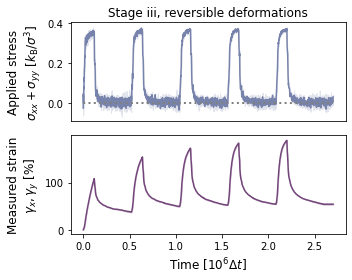

In [6]:
fig,ax = plt.subplots(2,1,figsize = (5,4))
#stressTotAv = np.add(stressXredAv,stressYredAv)
ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),stressTotAv,color = ClrsRici[0])
ax[0].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(stressTotAv,-stressTotStd),np.add(stressTotAv,stressTotStd),color = ClrsRici[0],alpha = 0.2)
ax[0].set_ylabel('Applied stress\n'+r'$\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.zeros(len(Time[:T_End])),linestyle = ':',color= 'grey',linewidth = 2)
ax[0].set_xticks([])
#ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.mean([np.add(np.divide(np.multiply(xbox[:T_End],100),xbox[0]),-100),np.add(np.divide(np.multiply(ybox[:T_End],100),ybox[0]),-100)],axis = 0),color = ClrsRici[2])
ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),meanstrainAv,color = ClrsRici[2])
ax[1].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(meanstrainAv,meanstrainStd),np.add(meanstrainAv,-meanstrainStd),color = ClrsRici[2],alpha = 0.2)
ax[1].set_ylabel('Measured strain\n'+r'$\gamma_{x},\gamma_{y}~[\%]$',fontsize = 12)
ax[1].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
ax[0].set_title("Stage iii, reversible deformations",fontsize = 12)
#ax[1].set_ylim([1,800])
#ax[1].set_yscale('log')
fig.tight_layout()
#plotname = "Reversible_StressSeedsPress.pdf"
#fig.savefig(plotsdir+plotname)



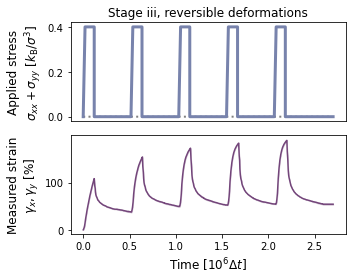

In [7]:
fig,ax = plt.subplots(2,1,figsize = (5,4))
#stressTotAv = np.add(stressXredAv,stressYredAv)
#ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),stressTotAv,color = ClrsRici[0])
#ax[0].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(stressTotAv,-stressTotStd),np.add(stressTotAv,stressTotStd),color = ClrsRici[0],alpha = 0.2)
appliedStress = []
Times = []
tstretch = 2e4
t_cycrel = 1e5
TimeFullCycle = tstretch+t_cycrel*5
stressFinal = 0.4
for i in range(5):
    appliedStress.append(0)
    Times.append(0+i*(TimeFullCycle))
    appliedStress.append(stressFinal)
    Times.append(tstretch+i*(TimeFullCycle))
    
    appliedStress.append(stressFinal)
    Times.append(t_cycrel+tstretch+i*(TimeFullCycle))
    
    appliedStress.append(0)
    Times.append(t_cycrel+tstretch+i*(TimeFullCycle))
appliedStress.append(0)
Times.append(t_cycrel+tstretch+(i+1)*(TimeFullCycle))
    
ax[0].set_ylabel('Applied stress\n'+r'$\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.zeros(len(Time[:T_End])),linestyle = ':',color= 'grey',linewidth = 2)
ax[0].set_xticks([])
#ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.mean([np.add(np.divide(np.multiply(xbox[:T_End],100),xbox[0]),-100),np.add(np.divide(np.multiply(ybox[:T_End],100),ybox[0]),-100)],axis = 0),color = ClrsRici[2])
ax[0].plot(np.divide(Times,1e6),appliedStress, ClrsRici[0],linewidth = 3)
ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),meanstrainAv,color = ClrsRici[2])
ax[1].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(meanstrainAv,meanstrainStd),np.add(meanstrainAv,-meanstrainStd),color = ClrsRici[2],alpha = 0.2)

# ax[1].fill_between([0.12,.12+.2],[0,0],[160,160],alpha =0.1,color = 'black')
# ax[1].fill_between([0.,.12],[0,0],[160,160],alpha =0.05,color = 'black')
# ax[1].fill_between([.12+.2,.12+.2+.12],[0,0],[160,160],alpha =0.05,color = 'black')
# ax[1].fill_between([.12+.2+.12,.12+.2+.12+0.2],[0,0],[160,160],alpha =0.1,color = 'black')
# ax[0].fill_between([0.12,.12+.2],[0,0],[0.22,0.22],alpha =0.1,color = 'black')
# ax[0].fill_between([0.,.12],[0,0],[0.22,0.22],alpha =0.05,color = 'black')
# ax[0].fill_between([.12+.2,.12+.2+.12],[0,0],[0.22,0.22],alpha =0.05,color = 'black')
# ax[0].fill_between([.12+.2+.12,.12+.2+.12+0.2],[0,0],[0.22,0.22],alpha =0.1,color = 'black')

ax[1].set_ylabel('Measured strain\n'+r'$\gamma_{x},\gamma_{y}~[\%]$',fontsize = 12)
ax[1].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
ax[0].set_title("Stage iii, reversible deformations",fontsize = 12)
#ax[1].set_ylim([1,800])
#ax[1].set_yscale('log')
fig.tight_layout()
#plotname = "Reversible_StressSeedsPressApplied"+Press[0]+".png"
#fig.savefig(plotsdir+plotname)